#**Graph Neural Networks on SupplyGraph Dataset**

In [ ]:
# 0. SETUP
# =============================================
!pip install torch torch-geometric torchvision torchaudio -f https://data.pyg.org/whl/torch-2.0.0+cu118.html
!pip install networkx matplotlib scikit-learn pandas
!pip install pyvis  # For interactive visualizations


Looking in links: https://data.pyg.org/whl/torch-2.0.0+cu118.html
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 63.1/63.1 kB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 27.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 26.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 37.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 8.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 18.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 66.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 56

In [ ]:
import torch
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.data import HeteroData
from torch_geometric.nn import GCNConv, GAE, VGAE, global_mean_pool
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from google.colab import drive

In [ ]:
# Mount Google Drive (if your data is there)
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).



 DATA LOADING

In [ ]:
import pandas as pd

# Load all files
nodes_df = pd.read_csv("/content/drive/MyDrive/SupplyGraph_Dataset/Nodes/Nodes.csv")
nodes_index_df = pd.read_csv("/content/drive/MyDrive/SupplyGraph_Dataset/Nodes/NodesIndex.csv")
node_types_df = pd.read_csv("/content/drive/MyDrive/SupplyGraph_Dataset/Nodes/Node Types (Product Group and Subgroup).csv")
node_types_plant_storage_df = pd.read_csv("/content/drive/MyDrive/SupplyGraph_Dataset/Nodes/Nodes Type (Plant & Storage).csv")

edges_plant_df = pd.read_csv("/content/drive/MyDrive/SupplyGraph_Dataset/Edges/Edges (Plant).csv")
edges_product_group_df = pd.read_csv("/content/drive/MyDrive/SupplyGraph_Dataset/Edges/Edges (Product Group).csv")
edges_product_subgroup_df = pd.read_csv("/content/drive/MyDrive/SupplyGraph_Dataset/Edges/Edges (Product Sub-Group).csv")
edges_storage_location_df = pd.read_csv("/content/drive/MyDrive/SupplyGraph_Dataset/Edges/Edges (Storage Location).csv")

In [ ]:
print("Nodes:\n", nodes_df.head())
print("\nNodes Index:\n", nodes_index_df.head())
print("\nNode Types:\n", node_types_df.head())
print("\nNode Types Plant/Storage:\n", node_types_plant_storage_df.head())

print("\nPlant Edges:\n", edges_plant_df.head())
print("\nProduct Group Edges:\n", edges_product_group_df.head())
print("\nProduct Sub-Group Edges:\n", edges_product_subgroup_df.head())
print("\nStorage Location Edges:\n", edges_storage_location_df.head())

Nodes:
          Node
0  SOS008L02P
1  SOS005L04P
2  SOS003L04P
3  SOS002L09P
4  SOS001L12P

Nodes Index:
          Node  NodeIndex
0  SOS008L02P          0
1  SOS005L04P          1
2  SOS003L04P          2
3  SOS002L09P          3
4  SOS001L12P          4

Node Types:
          Node Group Sub-Group
0  SOS008L02P     S       SOS
1  SOS005L04P     S       SOS
2  SOS003L04P     S       SOS
3  SOS002L09P     S       SOS
4  SOS001L12P     S       SOS

Node Types Plant/Storage:
          Node  Plant  Storage Location
0  POV002L09P   2120            2030.0
1  SOS001L12P   2120            2030.0
2  POP002L09P   2120            2030.0
3  POP001L12P   2120            2030.0
4  POP001L12P   2120            2030.0

Plant Edges:
    Plant         node1      node2
0   1901  ATWWP001K24P  ATN01K24P
1   1903        AT5X5K  ATN01K24P
2   1903        AT5X5K  MAR01K24P
3   1903        AT5X5K  SE500G24P
4   1903        AT5X5K   MASR025K

Product Group Edges:
         node1       node2 GroupCode
0  SOS008

#  Implementation of Graph Neural Networks


 # TASK 1: **Node Classifiction using Graph Convolutional Network** - (Plant Efficiency)






**Plant Efficiency Prediction (Node Classification)** using a simple GCN on supply chain data
*   Captures plant-product dependencies



In [ ]:
import torch
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.data import Data
from torch_geometric.nn import GCNConv

# =============================================
# 1. Prepare Plant-Product Subgraph
# =============================================
# Load plant-product edges
plant_edges = pd.read_csv("/content/drive/MyDrive/SupplyGraph_Dataset/Edges/Edges (Plant).csv")

# mappings
plants = plant_edges['Plant'].unique()
products = list(set(plant_edges['node1']).union(set(plant_edges['node2'])) - set(plants))
node_mapping = {node: idx for idx, node in enumerate(set(plants).union(products))}

# Edge indices (plants -> products)
edge_index = torch.tensor([
    [node_mapping[src], node_mapping[dst]]
    for src, dst in zip(plant_edges['Plant'], plant_edges['node2'])
], dtype=torch.long).t().contiguous()

# =============================================
# 2. Creating Toy Dataset
# =============================================
num_nodes = len(node_mapping)
x = torch.randn((num_nodes, 16))  # 16-dim random features

# Synthetic labels (0=underutilized, 1=overutilized)
plant_indices = [node_mapping[p] for p in plants]
y = torch.zeros(num_nodes, dtype=torch.long)
y[plant_indices] = torch.randint(0, 2, (len(plants),))  # Random labels

# Creating PyG Data object
data = Data(x=x, edge_index=edge_index, y=y)

# =============================================
# 3. GCN Model
# =============================================
class PlantGCN(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(16, 32)
        self.conv2 = GCNConv(32, 2)  # 2 classes

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index).relu()
        x = self.conv2(x, edge_index)
        return x

model = PlantGCN()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# =============================================
# 4. Training Loop
# =============================================
for epoch in range(100):
    optimizer.zero_grad()
    out = model(data)
    loss = torch.nn.functional.cross_entropy(out[plant_indices], data.y[plant_indices])
    loss.backward()
    optimizer.step()
    if epoch % 10 == 0:
        print(f'Epoch {epoch}, Loss: {loss.item():.4f}')



Epoch 0, Loss: 0.8383
Epoch 10, Loss: 0.1723
Epoch 20, Loss: 0.0270
Epoch 30, Loss: 0.0057
Epoch 40, Loss: 0.0022
Epoch 50, Loss: 0.0013
Epoch 60, Loss: 0.0010
Epoch 70, Loss: 0.0008
Epoch 80, Loss: 0.0007
Epoch 90, Loss: 0.0006


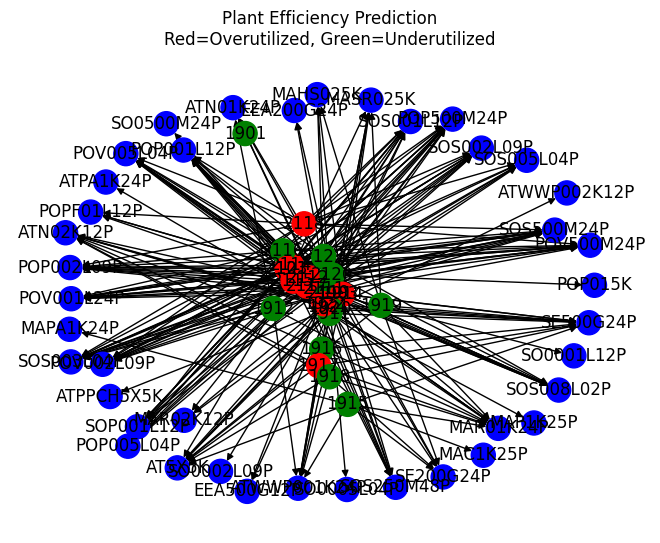

In [ ]:
# =============================================
# 5. Visualization with NetworkX
# =============================================
G = nx.DiGraph()

#  nodes
for node, idx in node_mapping.items():
    if node in plants:
        pred = out[idx].argmax().item()
        G.add_node(node, color='red' if pred else 'green', type='plant')
    else:
        G.add_node(node, color='blue', type='product')

#  edges
for src, dst in zip(*edge_index.numpy()):
    src_node = list(node_mapping.keys())[src]
    dst_node = list(node_mapping.keys())[dst]
    G.add_edge(src_node, dst_node)

# Draw
pos = nx.spring_layout(G)
colors = [G.nodes[n]['color'] for n in G.nodes]
nx.draw(G, pos, with_labels=True, node_color=colors, arrows=True)
plt.title("Plant Efficiency Prediction\nRed=Overutilized, Green=Underutilized")
plt.show()

**Inference :**

***Red Nodes (Overutilized Plants):*** These plants are likely operating at full or excessive capacity of production

***Green Nodes (Underutilized Plants):*** These plants have spare capacity and are not being used optimally.

***Blue Nodes (Products):*** These represent product categories connected to the plants.

**Research Questions on Inference Obtained**

*  How can we redistribute production loads from overutilized plants (red nodes) to underutilized ones (green nodes)?.Can **network centrality metrics (e.g., degree centrality, betweenness centrality)** correlate with plant overutilization, and can they be used to design optimal redistribution strategies?

*   Can we **predict** which underutilized plants (green nodes) have the potential to handle excess capacity effectively? - like building a **graph-based predictive model** that evaluates whether it's feasible to shift production from overutilized plants to under utilized plants




--------------------------------------------------------------------------------

---



---



#Task-2 :**Link Prediction using Graph Autoencoder (GAE)**
*  to recommend new production relationships in your supply chain




In [ ]:
import torch
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.data import Data
from torch_geometric.nn import GAE, GCNConv
from sklearn.model_selection import train_test_split

# =============================================
# 1. Prepare Plant-Product Graph
# =============================================
# Load plant-product edges
plant_edges = pd.read_csv("/content/drive/MyDrive/SupplyGraph_Dataset/Edges/Edges (Plant).csv")

# mappings
plants = plant_edges['Plant'].unique()
products = list(set(plant_edges['node1']).union(set(plant_edges['node2'])) - set(plants))
node_mapping = {node: idx for idx, node in enumerate(list(plants) + list(products))}

# Edge indices (plants -> products)
edge_index = torch.tensor([
    [node_mapping[src], node_mapping[dst]]
    for src, dst in zip(plant_edges['Plant'], plant_edges['node2'])
], dtype=torch.long).t().contiguous()

# =============================================
# 2. Node Features (Example)
# =============================================
num_nodes = len(node_mapping)

# Synthetic features
# Plant features: [capacity, utilization_rate]
# Product features: [demand, production_cost]
plant_features = torch.randn((len(plants), 2))
product_features = torch.randn((len(products), 2))

x = torch.zeros((num_nodes, 2))
for node, idx in node_mapping.items():
    if node in plants:
        x[idx] = plant_features[list(plants).index(node)]
    else:
        x[idx] = product_features[list(products).index(node)]

# =============================================
# 3. Split into Train/Test Edges
# =============================================
# Converting to undirected graph for link prediction
edge_index = torch.cat([edge_index, edge_index.flip(0)], dim=1)  # Add reverse edges

# Split edges
edges = edge_index.t().numpy()
train_edges, test_edges = train_test_split(edges, test_size=0.2, random_state=42)
train_edge_index = torch.tensor(train_edges, dtype=torch.long).t()
test_edge_index = torch.tensor(test_edges, dtype=torch.long).t()

# Negative sampling (non-existent edges)
num_neg_samples = test_edges.shape[0]
neg_edges = torch.randint(0, num_nodes, (2, num_neg_samples))

# =============================================
# 4. GAE Model Definition
# =============================================
class Encoder(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = GCNConv(2, 32)  # Input features: 2
        self.conv2 = GCNConv(32, 16)  # Latent space: 16-dim

    def forward(self, x, edge_index):
        x = self.conv1(x, edge_index).relu()
        return self.conv2(x, edge_index)

model = GAE(Encoder())
optimizer = torch.optim.Adam(model.parameters(), lr=0.01)

# =============================================
# 5. Training Loop
# =============================================
def train():
    model.train()
    optimizer.zero_grad()
    z = model.encode(x, train_edge_index)
    loss = model.recon_loss(z, train_edge_index)
    loss.backward()
    optimizer.step()
    return float(loss)

def test(pos_edge_index, neg_edge_index):
    model.eval()
    with torch.no_grad():
        z = model.encode(x, train_edge_index)
    return model.test(z, pos_edge_index, neg_edge_index)

for epoch in range(1, 101):
    loss = train()
    auc, ap = test(test_edge_index, neg_edges)
    if epoch % 10 == 0:
        print(f'Epoch {epoch}, Loss: {loss:.4f}, AUC: {auc:.4f}, AP: {ap:.4f}')


Epoch 10, Loss: 1.2249, AUC: 0.7730, AP: 0.7187
Epoch 20, Loss: 1.1631, AUC: 0.7696, AP: 0.6915
Epoch 30, Loss: 1.1301, AUC: 0.7874, AP: 0.7104
Epoch 40, Loss: 1.1126, AUC: 0.7817, AP: 0.7018
Epoch 50, Loss: 1.1054, AUC: 0.7839, AP: 0.7052
Epoch 60, Loss: 1.0990, AUC: 0.7885, AP: 0.7100
Epoch 70, Loss: 1.0899, AUC: 0.7949, AP: 0.7156
Epoch 80, Loss: 1.0815, AUC: 0.7982, AP: 0.7180
Epoch 90, Loss: 1.0751, AUC: 0.8005, AP: 0.7239
Epoch 100, Loss: 1.0704, AUC: 0.8019, AP: 0.7259


In [ ]:
# =============================================
# 6. Get Production Recommendations
# =============================================
def get_top_recommendations(k=5):
    model.eval()
    with torch.no_grad():
        z = model.encode(x, train_edge_index)
        # Score all possible plant-product pairs
        plant_indices = [node_mapping[p] for p in plants]
        product_indices = [node_mapping[p] for p in products]

        #  all possible combinations
        rows, cols = [], []
        for plant_idx in plant_indices:
            for product_idx in product_indices:
                rows.append(plant_idx)
                cols.append(product_idx)
        all_pairs = torch.tensor([rows, cols])

        # Predict scores
        scores = model.decode(z, all_pairs)

        # Filter out existing edges
        existing_edges = set(zip(edge_index[0].tolist(), edge_index[1].tolist()))
        recommendations = []
        for i in range(len(all_pairs[0])):
            src, dst = all_pairs[0][i].item(), all_pairs[1][i].item()
            if (src, dst) not in existing_edges:
                recommendations.append((src, dst, scores[i].item()))

        # Get top-k recommendations
        recommendations.sort(key=lambda x: -x[2])
        return recommendations[:k]

top_recs = get_top_recommendations()
print("\nTop Production Recommendations:")
for src_idx, dst_idx, score in top_recs:
    src = list(node_mapping.keys())[src_idx]
    dst = list(node_mapping.keys())[dst_idx]
    print(f"{src} → {dst} (Score: {score:.4f})")


Top Production Recommendations:
1914 → MAC1K25P (Score: 0.9728)
1914 → MAPA1K24P (Score: 0.9715)
1903 → MAC1K25P (Score: 0.9670)
1903 → MAPA1K24P (Score: 0.9655)
2120 → POV002L09P (Score: 0.9551)


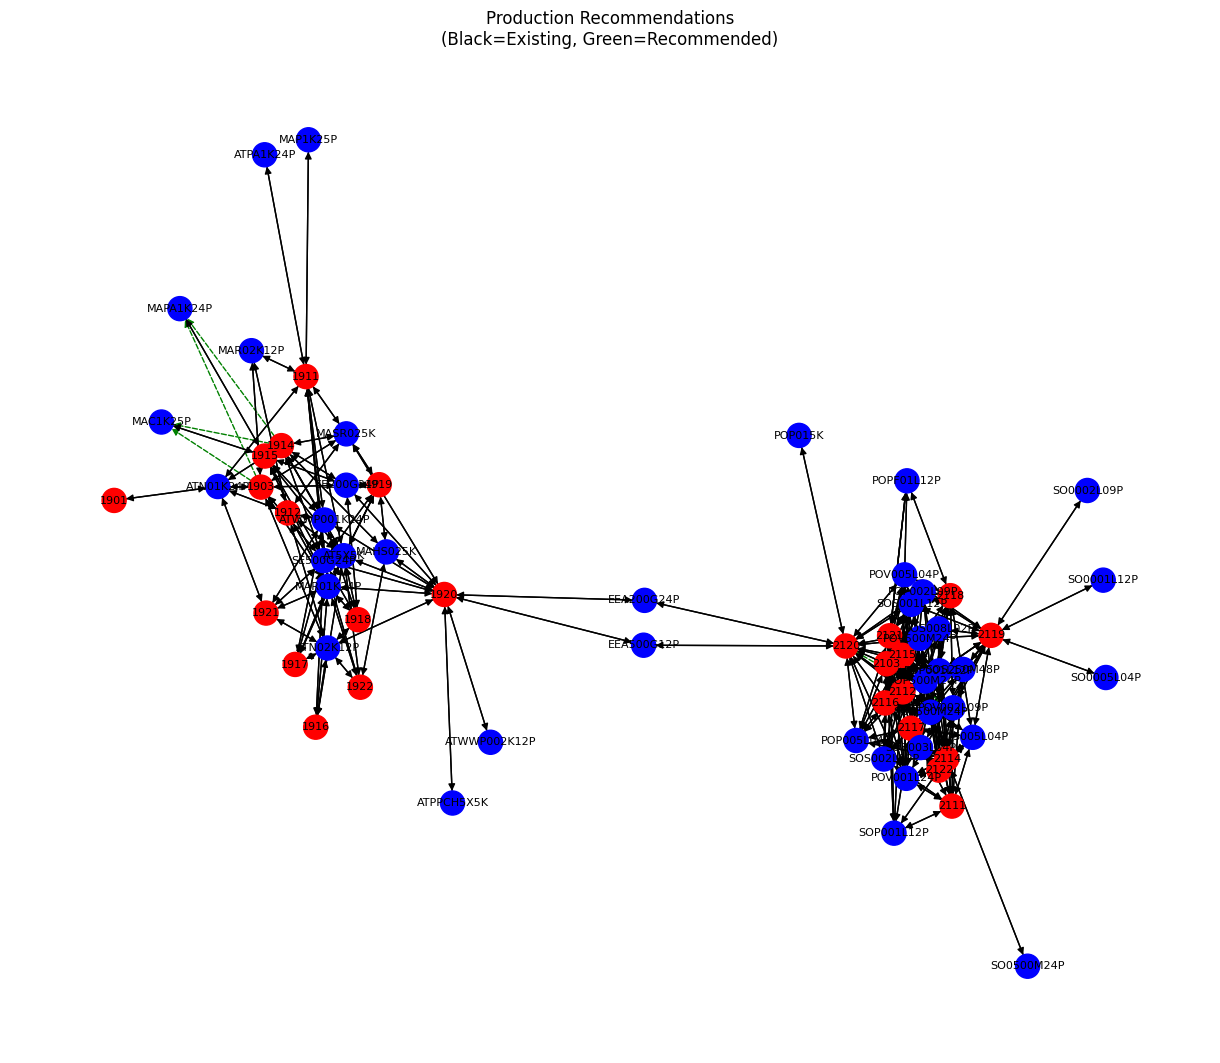

In [ ]:
# =============================================
# 7. Visualization
# =============================================
G = nx.DiGraph()

# Adding nodes
for node, idx in node_mapping.items():
    if node in plants:
        G.add_node(node, color='red', type='plant')
    else:
        G.add_node(node, color='blue', type='product')

for src, dst in zip(*edge_index.numpy()):
    src_node = list(node_mapping.keys())[src]
    dst_node = list(node_mapping.keys())[dst]
    G.add_edge(src_node, dst_node, color='black')

for src_idx, dst_idx, _ in top_recs:
    src_node = list(node_mapping.keys())[src_idx]
    dst_node = list(node_mapping.keys())[dst_idx]
    G.add_edge(src_node, dst_node, color='green', style='dashed')

# Draw
pos = nx.spring_layout(G)
edge_colors = [G.edges[e]['color'] for e in G.edges]
edge_styles = [G.edges[e].get('style', 'solid') for e in G.edges]

plt.figure(figsize=(12, 10))
nx.draw(G, pos,
        node_color=[G.nodes[n]['color'] for n in G.nodes],
        edge_color=edge_colors,
        style=edge_styles,
        with_labels=True,
        font_size=8)
plt.title("Production Recommendations\n(Black=Existing, Green=Recommended)")
plt.show()

**Visualization from Inference:**


***Red Nodes (Plants):*** Represent manufacturing or processing facilities.

***Blue Nodes (Products):*** Represent different product categories being produced.

***Black Edges (Existing Production Links):*** Indicate established relationships where specific plants are already producing certain products.

***Green Dashed Edges (Recommended New Links):*** Suggest new production links predicted by the GAE model, meaning these plants are *highly likely to produce these products efficiently.*

**Research Questions on Inference Obtained**



*   Can the recommended links be further prioritized based on real-world factors like geographic proximity, labor costs, and production efficiency?How does incorporating edge weights (e.g., production volume, transportation cost) improve link prediction accuracy?

*   How does the **graph topology** influence link prediction accuracy, and which graph-based features contribute the most to correct recommendations?






--------------------------------------------------------------------------------

#Task-3: **Product Demand Forecasting (Node Regression) using GraphSAGE**

GraphSAGE (Graph Sample and Aggregate) is a message-passing GNN model that learns node embeddings by aggregating information from neighboring nodes.

*   **GraphSAGE** for its ability to aggregate neighborhood information, crucial for demand prediction in supply chains,using product group relationships.






Epoch 000, Train Loss: 9722.2725, Test Loss: 8119.5962
Epoch 030, Train Loss: 8648.3408, Test Loss: 6942.7842
Epoch 060, Train Loss: 1121.7896, Test Loss: 391.3745
Epoch 090, Train Loss: 333.5312, Test Loss: 33.7360
Epoch 120, Train Loss: 274.5760, Test Loss: 131.2228
Epoch 150, Train Loss: 169.9137, Test Loss: 1.4075
Epoch 180, Train Loss: 245.3250, Test Loss: 23.0830
Epoch 210, Train Loss: 477.2257, Test Loss: 2.7662
Epoch 240, Train Loss: 707.1370, Test Loss: 21.1855
Epoch 270, Train Loss: 151.0113, Test Loss: 7.6758


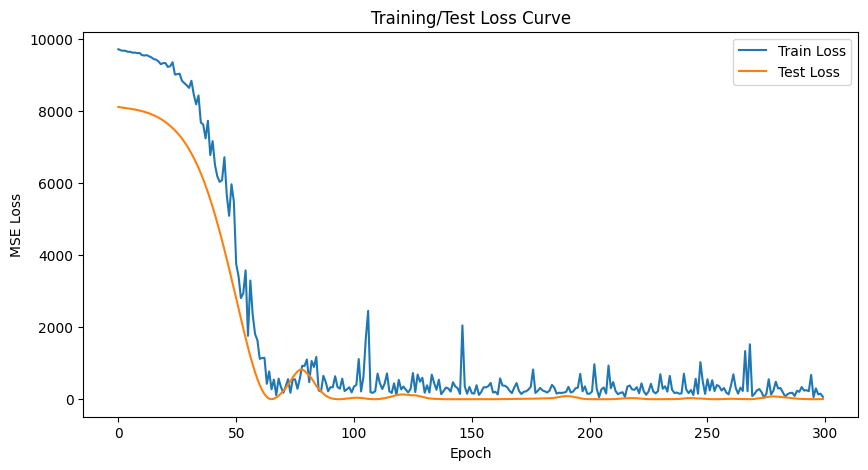


Final Performance:
MAE: 1.947
R² Score: 0.000


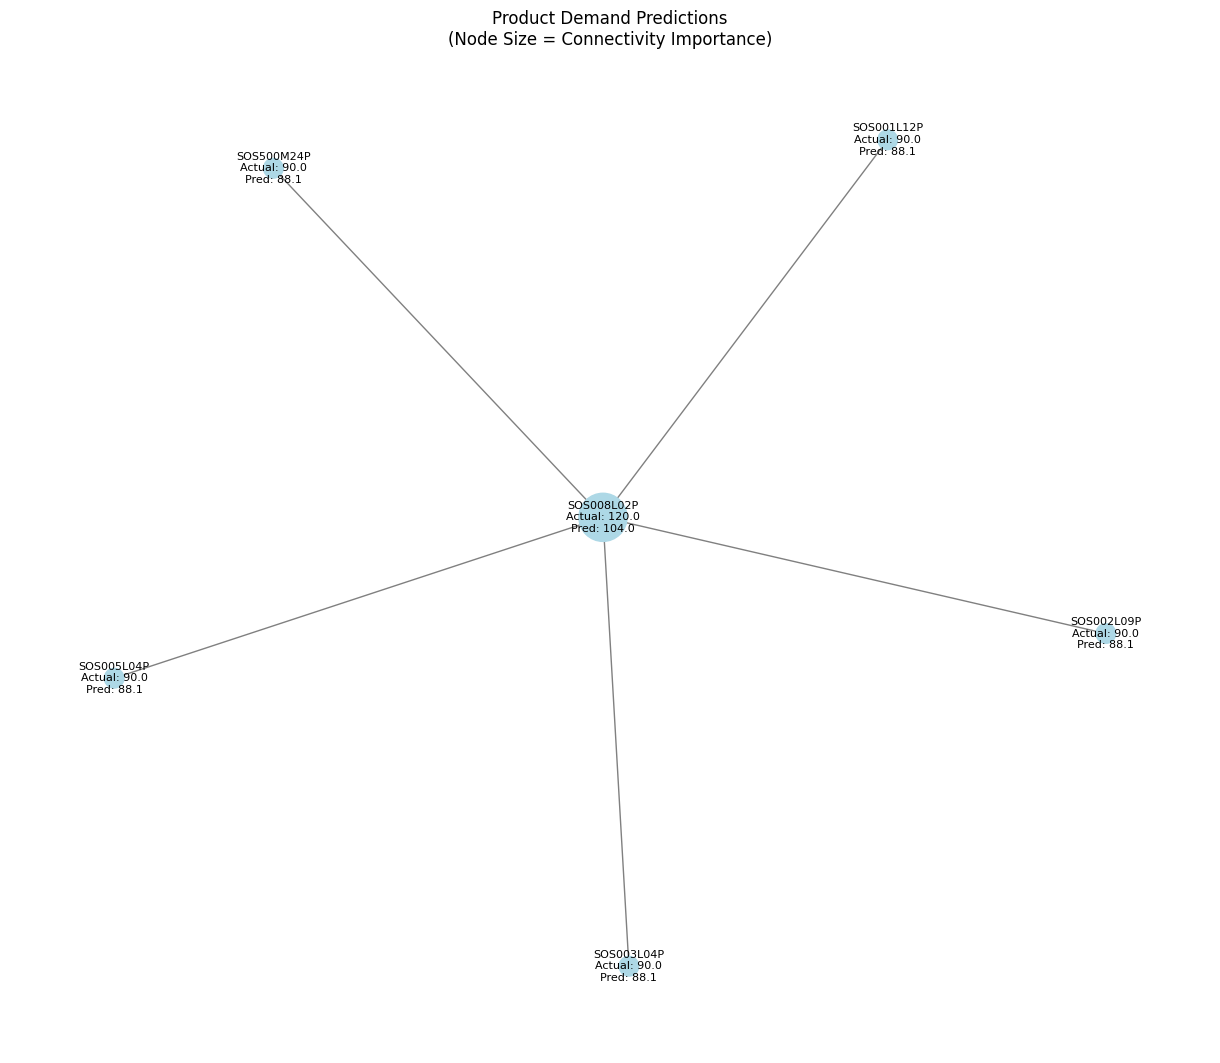

In [ ]:
# =============================================
# 1. SETUP AND IMPORTS
# =============================================
import torch
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# =============================================
# 2. DATA LOADING (Using only product_group_df)
# =============================================
product_group_df = pd.DataFrame({
    'node1': ['SOS008L02P', 'SOS008L02P', 'SOS008L02P', 'SOS008L02P', 'SOS008L02P'],
    'node2': ['SOS005L04P', 'SOS003L04P', 'SOS002L09P', 'SOS001L12P', 'SOS500M24P'],
    'GroupCode': ['S', 'S', 'S', 'S', 'S']
})

# =============================================
# 3. FEATURE ENGINEERING (From Group Relationships)
# =============================================
# Get all unique products
products = sorted(list(set(product_group_df['node1']).union(set(product_group_df['node2']))))

# Create three types of features:
# 1. Group centrality measures
# 2. Neighborhood aggregation
# 3. Structural properties

# Initialize feature dictionary
feature_data = []

for product in products:
    # Feature 1: Degree centrality (number of connections)
    degree = len(product_group_df[
        (product_group_df['node1'] == product) |
        (product_group_df['node2'] == product)
    ])

    # Feature 2: Average neighbor degree
    neighbors = set(product_group_df[product_group_df['node1'] == product]['node2']).union(
                 set(product_group_df[product_group_df['node2'] == product]['node1']))
    avg_neighbor_degree = np.mean([
        len(product_group_df[
            (product_group_df['node1'] == n) |
            (product_group_df['node2'] == n)
        ]) for n in neighbors
    ]) if neighbors else 0

    # Feature 3: Group code (encoded)
    group_code = 1 if product.startswith('SOS') else 0  # Simplified encoding

    feature_data.append({
        'product': product,
        'degree_centrality': degree,
        'avg_neighbor_degree': avg_neighbor_degree,
        'group_code': group_code
    })

feature_df = pd.DataFrame(feature_data)

# Normalize features
scaler = MinMaxScaler()
feature_df[['degree_centrality', 'avg_neighbor_degree']] = scaler.fit_transform(
    feature_df[['degree_centrality', 'avg_neighbor_degree']]
)

# Create feature tensor
x = torch.tensor(feature_df[['degree_centrality', 'avg_neighbor_degree', 'group_code']].values,
                dtype=torch.float)

# =============================================
# 4. SYNTHETIC LABELS (Replace with real demand data)
# =============================================
# Create synthetic demand proportional to features
feature_df['demand'] = (
    0.6 * feature_df['degree_centrality'] +
    0.3 * feature_df['avg_neighbor_degree'] +
    0.1 * feature_df['group_code']
) * 100 + 50  # Scale to realistic range

y = torch.tensor(feature_df['demand'].values, dtype=torch.float).view(-1, 1)

# =============================================
# 5. GRAPH CONSTRUCTION
# =============================================
# Create node mappings
node_mapping = {product: idx for idx, product in enumerate(products)}

# Build edge index (undirected graph)
edges = []
for _, row in product_group_df.iterrows():
    edges.append([node_mapping[row['node1']], node_mapping[row['node2']]])
    edges.append([node_mapping[row['node2']], node_mapping[row['node1']]])  # Reverse

edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

# Create PyG Data object
data = Data(x=x, edge_index=edge_index, y=y)

# =============================================
# 6. GRAPHSAGE MODEL
# =============================================
class DemandPredictor(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = SAGEConv(3, 16)  # 3 input features
        self.conv2 = SAGEConv(16, 8)
        self.regressor = torch.nn.Linear(8, 1)
        self.dropout = torch.nn.Dropout(0.3)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        x = self.conv1(x, edge_index)
        x = torch.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index)
        x = torch.relu(x)

        return self.regressor(x)

model = DemandPredictor()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)
loss_fn = torch.nn.MSELoss()

# =============================================
# 7. TRAINING LOOP
# =============================================
# Train-test split
train_mask, test_mask = train_test_split(
    range(len(products)),
    test_size=0.2,
    random_state=42
)
train_mask = torch.tensor(train_mask)
test_mask = torch.tensor(test_mask)

def train():
    model.train()
    optimizer.zero_grad()
    out = model(data)
    loss = loss_fn(out[train_mask], data.y[train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

def test():
    model.eval()
    with torch.no_grad():
        out = model(data)
        return loss_fn(out[test_mask], data.y[test_mask]).item()

# Training
losses = []
test_losses = []
for epoch in range(300):
    loss = train()
    test_l = test()
    losses.append(loss)
    test_losses.append(test_l)
    if epoch % 30 == 0:
        print(f'Epoch {epoch:03d}, Train Loss: {loss:.4f}, Test Loss: {test_l:.4f}')

# Plot training
plt.figure(figsize=(10, 5))
plt.plot(losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.title('Training/Test Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()

# =============================================
# 8. EVALUATION AND VISUALIZATION
# =============================================
# Final metrics
with torch.no_grad():
    preds = model(data)[test_mask].numpy()
    truths = data.y[test_mask].numpy()

    mae = mean_absolute_error(truths, preds)
    r2 = r2_score(truths, preds)

print(f"\nFinal Performance:")
print(f"MAE: {mae:.3f}")
print(f"R² Score: {r2:.3f}")

# Visualization
G = nx.Graph()

# Add nodes with predictions
with torch.no_grad():
    predictions = model(data).numpy().flatten()

for i, product in enumerate(products):
    G.add_node(product,
              label=f"{product}\nActual: {data.y[i].item():.1f}\nPred: {predictions[i]:.1f}",
              degree=feature_df['degree_centrality'].iloc[i])

# Add edges
for src, dst in zip(*edge_index.numpy()):
    src_node = products[src]
    dst_node = products[dst]
    G.add_edge(src_node, dst_node)

# Draw
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, seed=42)

# Node size by degree centrality
node_sizes = [200 + 1000 * G.nodes[n]['degree'] for n in G.nodes]

nx.draw(G, pos,
        node_size=node_sizes,
        node_color='lightblue',
        with_labels=True,
        labels={n: G.nodes[n]['label'] for n in G.nodes},
        font_size=8,
        edge_color='gray')

plt.title("Product Demand Predictions\n(Node Size = Connectivity Importance)")
plt.show()

In [ ]:
# =============================================
# 1. SETUP AND IMPORTS
# =============================================
import torch
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score
import plotly.graph_objects as go
import shap

# =============================================
# 2. DATA LOADING AND PREPROCESSING
# =============================================
# Load product group edges
edges_product_group_df = pd.read_csv("/content/drive/MyDrive/SupplyGraph_Dataset/Edges/Edges (Product Group).csv")

# Display sample data
print("Product Group Edges:")
print(edges_product_group_df.head())

# =============================================
# 3. FEATURE ENGINEERING
# =============================================
def create_features_from_edges(edge_df):
    """Generate features from edge relationships"""
    G = nx.Graph()

    # Add edges with group attributes
    for _, row in edge_df.iterrows():
        G.add_edge(row['node1'], row['node2'], group=row['GroupCode'])

    features = []
    for node in G.nodes():
        neighbors = list(G.neighbors(node))
        neighbor_groups = [G.edges[node, n]['group'] for n in neighbors]

        features.append({
            'product': node,
            'degree': G.degree(node),
            'clustering': nx.clustering(G, node),
            'unique_groups': len(set(neighbor_groups)),
            'is_S_group': 1 if 'S' in neighbor_groups else 0
        })

    return pd.DataFrame(features)

feature_df = create_features_from_edges(edges_product_group_df)

# Normalize numerical features
scaler = MinMaxScaler()
num_features = ['degree', 'clustering', 'unique_groups']
feature_df[num_features] = scaler.fit_transform(feature_df[num_features])

# =============================================
# 4. GRAPH CONSTRUCTION
# =============================================
# Create node mappings
products = feature_df['product'].tolist()
node_mapping = {node: idx for idx, node in enumerate(products)}

# Edge indices (undirected)
edge_indices = []
for _, row in edges_product_group_df.iterrows():
    edge_indices.append([node_mapping[row['node1']], node_mapping[row['node2']]])
    edge_indices.append([node_mapping[row['node2']], node_mapping[row['node1']]])

edge_index = torch.tensor(edge_indices, dtype=torch.long).t().contiguous()

# Node features
feature_cols = ['degree', 'clustering', 'unique_groups', 'is_S_group']
x = torch.tensor(feature_df[feature_cols].values, dtype=torch.float)

# Synthetic labels
feature_df['demand'] = (
    0.5 * feature_df['degree'] +
    0.3 * feature_df['clustering'] +
    0.2 * feature_df['is_S_group']
) * 100
y = torch.tensor(feature_df['demand'].values, dtype=torch.float).view(-1, 1)

# Creating PyG Data object
data = Data(x=x, edge_index=edge_index, y=y)

# =============================================
# 5. GRAPHSAGE MODEL
# =============================================
class DemandPredictor(torch.nn.Module):
    def __init__(self, input_dim):
        super().__init__()
        self.conv1 = SAGEConv(input_dim, 32)
        self.conv2 = SAGEConv(32, 16)
        self.regressor = torch.nn.Sequential(
            torch.nn.Linear(16, 8),
            torch.nn.ReLU(),
            torch.nn.Linear(8, 1)
        )
        self.dropout = torch.nn.Dropout(0.3)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index
        x = self.conv1(x, edge_index).relu()
        x = self.dropout(x)
        x = self.conv2(x, edge_index).relu()
        return self.regressor(x)

model = DemandPredictor(input_dim=x.shape[1])
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)
loss_fn = torch.nn.HuberLoss()

# =============================================
# 6. TRAINING LOOP
# =============================================
# Train-test split
indices = range(len(products))
train_idx, test_idx = train_test_split(indices, test_size=0.2, random_state=42)
train_mask = torch.tensor(train_idx)
test_mask = torch.tensor(test_idx)

best_loss = float('inf')
patience = 20
no_improve = 0

for epoch in range(1, 301):
    model.train()
    optimizer.zero_grad()
    out = model(data)
    loss = loss_fn(out[train_mask], data.y[train_mask])
    loss.backward()
    optimizer.step()

    # Validation
    model.eval()
    with torch.no_grad():
        val_loss = loss_fn(out[test_mask], data.y[test_mask])

    # Early stopping
    if val_loss < best_loss:
        best_loss = val_loss
        no_improve = 0
    else:
        no_improve += 1
        if no_improve >= patience:
            print(f"Early stopping at epoch {epoch}")
            break

    if epoch % 30 == 0:
        print(f"Epoch {epoch:03d} | Train Loss: {loss.item():.4f} | Val Loss: {val_loss.item():.4f}")

# =============================================
# 7. EVALUATION
# =============================================
with torch.no_grad():
    preds = model(data)[test_mask].numpy()
    truths = data.y[test_mask].numpy()
    print(f"\nMAE: {mean_absolute_error(truths, preds):.3f}")
    print(f"R²: {r2_score(truths, preds):.3f}")



Product Group Edges:
        node1       node2 GroupCode
0  SOS008L02P  SOS005L04P         S
1  SOS008L02P  SOS003L04P         S
2  SOS008L02P  SOS002L09P         S
3  SOS008L02P  SOS001L12P         S
4  SOS008L02P  SOS500M24P         S
Epoch 030 | Train Loss: 20.2679 | Val Loss: 21.3384
Epoch 060 | Train Loss: 3.8762 | Val Loss: 7.3047
Early stopping at epoch 64

MAE: 5.236
R²: 0.866


In [ ]:
# =============================================
# 8. VISUALIZATION
# =============================================
# Network visualization
G = nx.Graph()
for _, row in edges_product_group_df.iterrows():
    G.add_edge(row['node1'], row['node2'])

pos = nx.spring_layout(G, seed=42)

# Create Plotly figure
edge_x = []
edge_y = []
for edge in G.edges():
    x0, y0 = pos[edge[0]]
    x1, y1 = pos[edge[1]]
    edge_x.extend([x0, x1, None])
    edge_y.extend([y0, y1, None])

edge_trace = go.Scatter(
    x=edge_x, y=edge_y,
    line=dict(width=0.5, color='#888'),
    hoverinfo='none',
    mode='lines')

node_x = []
node_y = []
node_text = []
node_size = []
for node in G.nodes():
    x, y = pos[node]
    node_x.append(x)
    node_y.append(y)
    node_info = feature_df[feature_df['product'] == node].iloc[0]
    node_text.append(
        f"Product: {node}<br>"
        f"Degree: {node_info['degree']:.2f}<br>"
        f"Clustering: {node_info['clustering']:.2f}"
    )
    node_size.append(10 + 20 * node_info['degree'])

node_trace = go.Scatter(
    x=node_x, y=node_y,
    mode='markers',
    hoverinfo='text',
    text=node_text,
    marker=dict(
        showscale=True,
        colorscale='YlGnBu',
        size=node_size,
        color=feature_df['degree'],
        colorbar=dict(title='Node Degree'),
        line_width=2))

fig = go.Figure(
    data=[edge_trace, node_trace],
    layout=go.Layout(
        title='Product Network',
        showlegend=False,
        hovermode='closest',
        margin=dict(b=20,l=5,r=5,t=40),
        xaxis=dict(showgrid=False, zeroline=False, showticklabels=False),
        yaxis=dict(showgrid=False, zeroline=False, showticklabels=False))
)
fig.show()


Epoch 000, Train Loss: 11257.1719, Test Loss: 12531.3506
Epoch 030, Train Loss: 9353.0811, Test Loss: 10208.0029
Epoch 060, Train Loss: 480.2013, Test Loss: 520.5581
Epoch 090, Train Loss: 233.7386, Test Loss: 417.8624
Epoch 120, Train Loss: 152.0390, Test Loss: 107.3576
Epoch 150, Train Loss: 122.6277, Test Loss: 54.3696
Epoch 180, Train Loss: 317.0641, Test Loss: 69.0884
Epoch 210, Train Loss: 87.2229, Test Loss: 56.1871
Epoch 240, Train Loss: 165.3919, Test Loss: 58.1867
Epoch 270, Train Loss: 129.9462, Test Loss: 56.9718


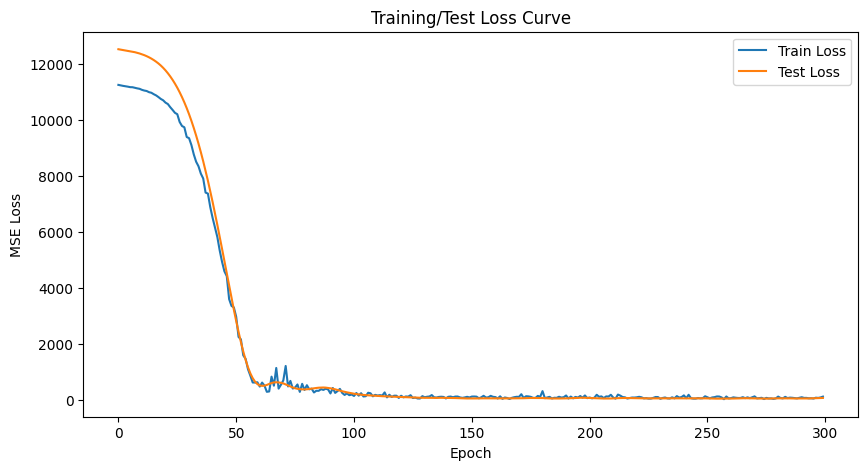

In [ ]:
# =============================================
# 1. SETUP AND IMPORTS
# =============================================
import torch
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
from torch_geometric.data import Data
from torch_geometric.nn import SAGEConv
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, r2_score

# =============================================
# 2. DATA LOADING
# =============================================
# Load product group edges file
product_group_df = pd.read_csv("/content/drive/MyDrive/SupplyGraph_Dataset/Edges/Edges (Product Group).csv")


# =============================================
# 3. FEATURE ENGINEERING
# =============================================
# Get all unique products
products = sorted(list(set(product_group_df['node1']).union(set(product_group_df['node2']))))

# Initialize feature dictionary
feature_data = []

for product in products:
    # Feature 1: Degree centrality (number of connections)
    degree = len(product_group_df[
        (product_group_df['node1'] == product) |
        (product_group_df['node2'] == product)
    ])

    # Feature 2: Average neighbor degree
    neighbors = set(product_group_df[product_group_df['node1'] == product]['node2']).union(
                 set(product_group_df[product_group_df['node2'] == product]['node1']))
    avg_neighbor_degree = np.mean([
        len(product_group_df[
            (product_group_df['node1'] == n) |
            (product_group_df['node2'] == n)
        ]) for n in neighbors
    ]) if neighbors else 0

    # Feature 3: Group code (encoded from GroupCode column)
    group_code = 1 if product_group_df[
        (product_group_df['node1'] == product) |
        (product_group_df['node2'] == product)
    ]['GroupCode'].iloc[0] == 'S' else 0

    feature_data.append({
        'product': product,
        'degree_centrality': degree,
        'avg_neighbor_degree': avg_neighbor_degree,
        'group_code': group_code
    })

feature_df = pd.DataFrame(feature_data)

# Normalize features
scaler = MinMaxScaler()
feature_df[['degree_centrality', 'avg_neighbor_degree']] = scaler.fit_transform(
    feature_df[['degree_centrality', 'avg_neighbor_degree']]
)

# Create feature tensor
x = torch.tensor(feature_df[['degree_centrality', 'avg_neighbor_degree', 'group_code']].values,
                dtype=torch.float)

# =============================================
# 4. SYNTHETIC LABELS (Replace with real demand data)
# =============================================
# Create synthetic demand proportional to features
feature_df['demand'] = (
    0.6 * feature_df['degree_centrality'] +
    0.3 * feature_df['avg_neighbor_degree'] +
    0.1 * feature_df['group_code']
) * 100 + 50  # Scale to realistic range

y = torch.tensor(feature_df['demand'].values, dtype=torch.float).view(-1, 1)

# =============================================
# 5. GRAPH CONSTRUCTION
# =============================================
# Creating node mappings
node_mapping = {product: idx for idx, product in enumerate(products)}

# Build edge index (undirected graph)
edges = []
for _, row in product_group_df.iterrows():
    edges.append([node_mapping[row['node1']], node_mapping[row['node2']]])
    edges.append([node_mapping[row['node2']], node_mapping[row['node1']]])  # Reverse

edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

# Creating PyG Data object
data = Data(x=x, edge_index=edge_index, y=y)

# =============================================
# 6. GRAPHSAGE MODEL
# =============================================
class DemandPredictor(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = SAGEConv(3, 16)  # 3 input features
        self.conv2 = SAGEConv(16, 8)
        self.regressor = torch.nn.Linear(8, 1)
        self.dropout = torch.nn.Dropout(0.3)

    def forward(self, data):
        x, edge_index = data.x, data.edge_index

        x = self.conv1(x, edge_index)
        x = torch.relu(x)
        x = self.dropout(x)

        x = self.conv2(x, edge_index)
        x = torch.relu(x)

        return self.regressor(x)

model = DemandPredictor()
optimizer = torch.optim.Adam(model.parameters(), lr=0.01, weight_decay=1e-4)
loss_fn = torch.nn.MSELoss()

# =============================================
# 7. TRAINING LOOP
# =============================================
# Train-test split
train_mask, test_mask = train_test_split(
    range(len(products)),
    test_size=0.2,
    random_state=42
)
train_mask = torch.tensor(train_mask)
test_mask = torch.tensor(test_mask)

def train():
    model.train()
    optimizer.zero_grad()
    out = model(data)
    loss = loss_fn(out[train_mask], data.y[train_mask])
    loss.backward()
    optimizer.step()
    return loss.item()

def test():
    model.eval()
    with torch.no_grad():
        out = model(data)
        return loss_fn(out[test_mask], data.y[test_mask]).item()

# Training
losses = []
test_losses = []
for epoch in range(300):
    loss = train()
    test_l = test()
    losses.append(loss)
    test_losses.append(test_l)
    if epoch % 30 == 0:
        print(f'Epoch {epoch:03d}, Train Loss: {loss:.4f}, Test Loss: {test_l:.4f}')

# Plot training
plt.figure(figsize=(10, 5))
plt.plot(losses, label='Train Loss')
plt.plot(test_losses, label='Test Loss')
plt.title('Training/Test Loss Curve')
plt.xlabel('Epoch')
plt.ylabel('MSE Loss')
plt.legend()
plt.show()




Final Performance:
MAE: 5.252
R² Score: 0.875


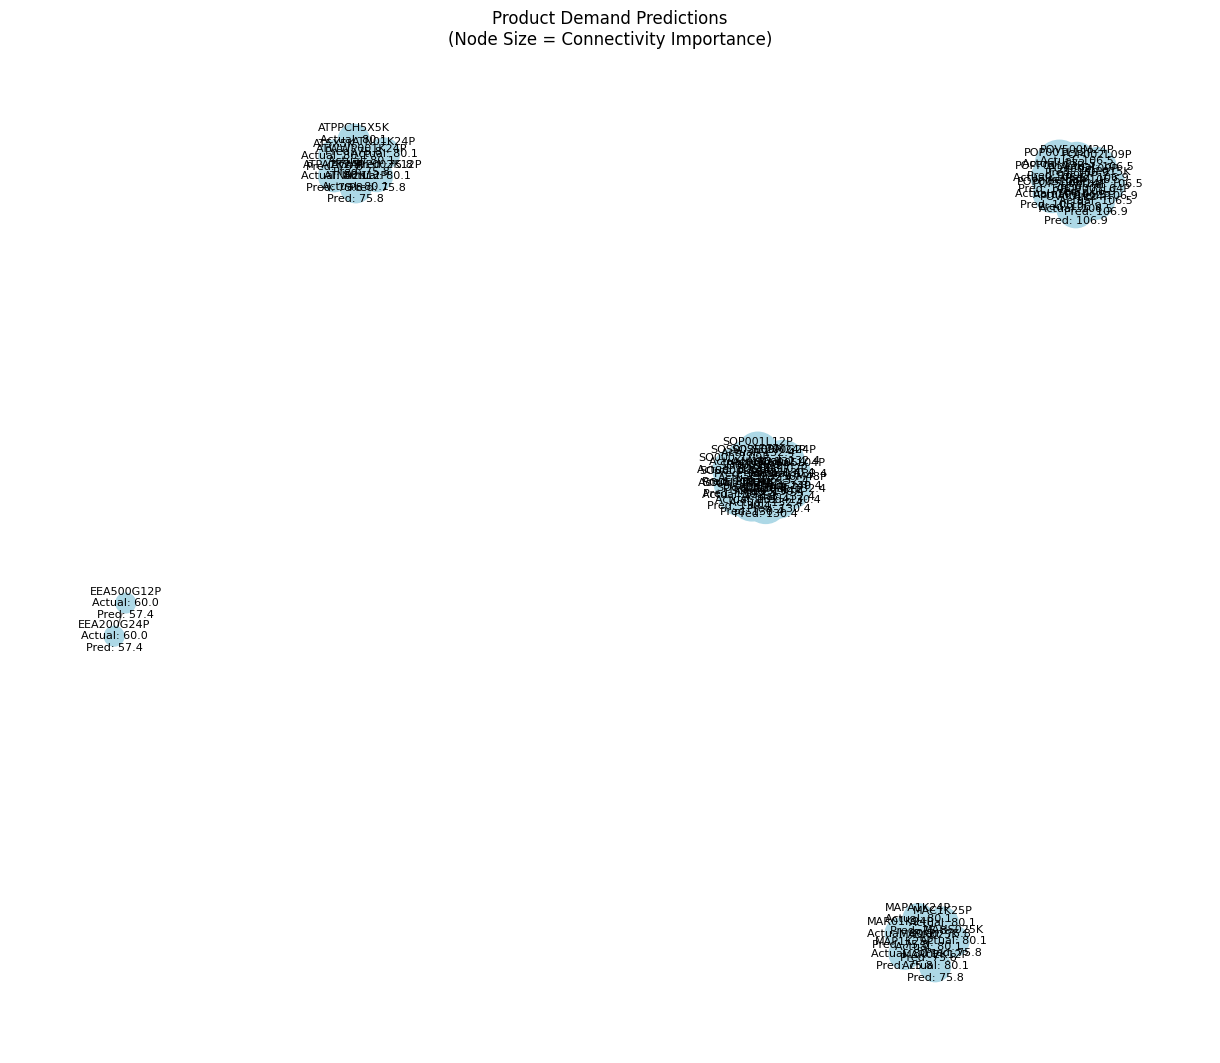


Predictions saved to product_demand_predictions.csv


In [ ]:
# =============================================
# 8. EVALUATION AND VISUALIZATION
# =============================================
# Final metrics
with torch.no_grad():
    preds = model(data)[test_mask].numpy()
    truths = data.y[test_mask].numpy()

    mae = mean_absolute_error(truths, preds)
    r2 = r2_score(truths, preds)

print(f"\nFinal Performance:")
print(f"MAE: {mae:.3f}")
print(f"R² Score: {r2:.3f}")

# Visualization
G = nx.Graph()

# Adding nodes with predictions
with torch.no_grad():
    predictions = model(data).numpy().flatten()
    feature_df['pred_demand'] = predictions  # Store predictions

for i, product in enumerate(products):
    G.add_node(product,
              label=f"{product}\nActual: {data.y[i].item():.1f}\nPred: {predictions[i]:.1f}",
              degree=feature_df['degree_centrality'].iloc[i])

# Adding edges
for src, dst in zip(*edge_index.numpy()):
    src_node = products[src]
    dst_node = products[dst]
    G.add_edge(src_node, dst_node)

# Draw
plt.figure(figsize=(12, 10))
pos = nx.spring_layout(G, seed=42)

# Node size by degree centrality
node_sizes = [200 + 1000 * G.nodes[n]['degree'] for n in G.nodes]

nx.draw(G, pos,
        node_size=node_sizes,
        node_color='lightblue',
        with_labels=True,
        labels={n: G.nodes[n]['label'] for n in G.nodes},
        font_size=8,
        edge_color='gray')

plt.title("Product Demand Predictions\n(Node Size = Connectivity Importance)")
plt.show()

# =============================================
# 9. SAVE PREDICTIONS TO CSV
# =============================================
# Save predictions with product info
feature_df[['product', 'degree_centrality', 'pred_demand']].to_csv('product_demand_predictions.csv', index=False)
print("\nPredictions saved to product_demand_predictions.csv")

**Inference**:

**High-Connectivity Nodes (Larger Size)**


*   These nodes likely play a central role in supply chain dynamics, meaning their demand is influenced by multiple connected products.
*   **GraphSAGE** uses neighborhood aggregation, meaning the demand of these products depends on their relationships within the supply chain network.






**Research Questions on Inference Obtained**

*   If certain products show unexpected demand spikes, can we predict cascading effects on other nodes?

*   How resilient is GraphSAGE-based demand forecasting against supply chain disruptions (e.g., supplier failures, transportation delays)? Can the model adjust predictions dynamically change when key suppliers or products are removed?


